### **부스팅 (boost)**

- 모델을 순차적으로 학습
- 이전 모델이 잘못 맞추거나 확률이 애매한 경우 데이터에 가중치를 증가 → 다음 모델에서 집중 학습
- 단순 모델들을 결합하여 강력 모델로 생성

- 장점
    - 편향 감소 → 예측의 확률이 올라간다
    - 단순한 모델들을 이어서 학습하기 때문에 성능이 많이 올라간다.

- 단점
    - 순차적으로 학습 → 병렬화 어려움 → 학습 속도가 느려짐
    - 학습의 횟수가 너무 많은 경우 → 과적합 위험
    - 파라미터 튜닝이 중요

- 대표 알고리즘
    - AdaBoost
        - 오차가 큰 샘플에 더 높은 가중치를 부여
        - 각각의 모델이 가중치가 조정된 데이터셋을 이용하여 학습
        - 최종 모델에서는 가중치의 합산으로 결정
    - Gradient Boosting(GBM)
        - 이전 모델의 잔차를 예측하는 새로운 모델을 추가
        - 손실 함수를 직접 최적화
        - 계산량이 많음
    - XGBoost
        - GBM을 개선한 알고리즘
        - 규제, 병렬 학습 지원 → 병렬 지원을 통해서 시간 감소, 규제를 통해서 과적합 방지
        - 대표적인 부스팅 알고리즘
        - 해당 모델은 라이브러리를 추가적으로 설치해야한다
    - LightGBM
        - XGBoost에 비해 속도 면에서 우수
        - 히스토그램 기반 학습을 통해서 대용량 데이터 처리에 특화
    - CatBoost
        - 범주형 데이터들을 자동 처리
        - 비교적으로 튜닝이 간단

#### **AdaBoost (분류)**

- 초기에는 모든 샘플의 가중치를 동일하게 부여
- 첫번째 모델에서는 약한 모델을 학습 → 잘못 분류한 샘플에 대해서 가중치를 증가
- 가중치가 증가한 데이터를 이용하여 다음 모델에서 학습하여 더 잘 맞히도록 집중 학습

- parameter

    - `estimator` (base_estimator 매개변수는 sklearn의 구버전에서 사용)
        - default : DecisionTreeClassifier(**max_depth = 1**)
        - model list
            - `DecisionTreeClassifier` : 매개변수의 값을 바꿔서 사용 가능
            - `LogisticRegressor` : 선형 분류 모델
            - `SVC(probability=True)` : 확률 예측을 True로 변경해야 사용 가능
    
    - `n_estimator`
        - default : 50
        - 일반적으로 50 ~ 500
        - 모델의 개수
            - 개수가 너무 많아지면 시간이 증가, 과적합 위험성 증가
    
    - `learning_rate`
        - default : 1.0
        - 각 단계별 기여도(가중치)
        - 일반적으로 0.1 ~ 1.0
        - `n_estimator`와 상호 보완적으로 설정 (rate를 작게 하면 모델 개수를 증가시킨다)
        - 약한 모델의 기여도를 조절하는 스케일링 값
        - 값이 작은 경우 → 각 단계별 영향이 줄어듬 → 많은 모델이 필요
        - 데이터의 크기 / 복잡도가 클수록 모델의 개수를 늘리고 기여도를 줄여주는 것이 유리
        - 데이터가 작은 경우 데이터의 개수를 줄이고 기여도를 증가시키는 게 유리
    
    - `algorithm`
        - default : SAMME.R
        - SAMME.R : 확률을 사용. 보통 시간이 빠르고 성능이 우수
        - SAMME : 클래스별 점수 기반 (확률이 필요 없음)

- 속성
    - `estimators_`
        - 학습된 모델들의 리스트
    - `estimators_weights_`
        - 각 모델들의 가중치 (분류 중요)
    - `estimators_errors_`
        - 각 단계별 오차율
    - `feature_infortances_`
        - feature별 중요도 (가중치의 합)

- 메서드
    - `staged_predict(X)` / `staged_predict_proba(X)`
        - 각 단계별 누적 모델의 예측을 순차적으로 제공 (학습 곡선)


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report

In [2]:
body = pd.read_csv('../data/bodyPerformance.csv')
body.head(3)

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C


In [ ]:
# gender column의 M → 0, F → 1
body['gender'] = body['gender'].map({'M': 0, 'F': 1})

In [ ]:
# class 변환
body['class'] = body['class'].map({'A': 1, 'B': 2, 'C': 3, 'D': 4})

In [5]:
body.info()

<class 'pandas.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  int64  
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  int64  
dtypes: float64(10), int64(2)
memory usage: 1.2 MB


In [6]:
X = body.drop('class', axis=1)
y = body['class']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [8]:
clf = AdaBoostClassifier()
clf.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [9]:
pred = clf.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           1       0.59      0.61      0.60       685
           2       0.41      0.49      0.45       662
           3       0.51      0.45      0.48       650
           4       0.78      0.70      0.73       682

    accuracy                           0.56      2679
   macro avg       0.57      0.56      0.57      2679
weighted avg       0.57      0.56      0.57      2679



In [10]:
clf2 = AdaBoostClassifier(
    n_estimators=500, learning_rate=0.1
)

In [11]:
clf2.fit(X_train, y_train)
pred2 = clf2.predict(X_test)
print(classification_report(y_test, pred2))

              precision    recall  f1-score   support

           1       0.51      0.68      0.58       685
           2       0.40      0.37      0.39       662
           3       0.48      0.45      0.46       650
           4       0.81      0.65      0.72       682

    accuracy                           0.54      2679
   macro avg       0.55      0.54      0.54      2679
weighted avg       0.55      0.54      0.54      2679



In [12]:
from sklearn.tree import DecisionTreeClassifier

clf3 = AdaBoostClassifier(
    estimator = DecisionTreeClassifier(max_depth = 4),
    n_estimators = 500,
    learning_rate = 0.1
)

In [13]:
clf3.fit(X_train, y_train)
pred3 = clf3.predict(X_test)
print(classification_report(y_test, pred3))

              precision    recall  f1-score   support

           1       0.75      0.78      0.76       685
           2       0.53      0.63      0.58       662
           3       0.66      0.62      0.64       650
           4       0.92      0.77      0.84       682

    accuracy                           0.70      2679
   macro avg       0.72      0.70      0.71      2679
weighted avg       0.72      0.70      0.71      2679



In [16]:
importances = clf3.feature_importances_
feature_df = pd.DataFrame(zip(X.columns, importances), columns = ['feature_name', 'importance'])

In [19]:
feature_df.sort_values('importance', ascending=False)

,feature_name,importance
8,sit and bend forward_cm,0.461715
9,sit-ups counts,0.198033
0,age,0.124704
3,weight_kg,0.052394
4,body fat_%,0.046553
7,gripForce,0.043737
10,broad jump_cm,0.027237
1,gender,0.023259
2,height_cm,0.017573
5,diastolic,0.003413


### AdaBoost (회귀)

- 여러 개의 약한 회귀 모델을 순차적으로 학습하여 이전 단계의 오차를 줄이도록 가중치를 조절하여 높은 성능의 회귀 모델을 생성

- parameter

    - `estimator`
        - default : DecisionTreeRegressor(max_depth = 3)
        - DecisionTreeRegressor : 매개변수들을 변경하여 사용 가능
        - LinearRegression : 선형 회귀 모델
        - Ridge : 릿지 모델(L2 패널티)
        - SVR : 서포트 벡터 머신 (max_iter 값 조절)
    
    - `loss`
        - default : linear
        - 오차에 대한 가중치의 변환 방식
        - linear : 기본적인 선형 업데이트
        - square : 제곱, 큰 오차에 더 민감하게 반응
        - exponential : 지수, 매우 큰 오차를 더 강하게 패널티

In [20]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [29]:
car = pd.read_csv('../data/CarPrice_Assignment.csv')

In [30]:
df = car.select_dtypes('number')

In [ ]:
df.drop('car_ID', axis=1, inplace = True)

In [32]:
X = df.drop('price', axis = 1)
y = df['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42
)

In [34]:
reg = AdaBoostRegressor()

In [101]:
reg.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [102]:
pred = reg.predict(X_test)

In [103]:
print('MAE: ', round(mean_absolute_error(y_test, pred), 2), '/ R²: ', round(r2_score(y_test, pred)*100, 2))

MAE:  2007.03 / R²:  90.53


In [104]:
reg2 = AdaBoostRegressor(n_estimators = 500, learning_rate = 0.1)

In [105]:
reg2.fit(X_train, y_train)
pred2 = reg2.predict(X_test)

print('MAE: ', round(mean_absolute_error(y_test, pred2), 2), '/ R²: ', round(r2_score(y_test, pred2)*100, 2))

MAE:  1937.55 / R²:  90.85


In [106]:
import matplotlib.pyplot as plt

In [107]:
# 각 단계별 예측값을 이용하여 MAE를 구하고 그래프로 시각화
list(reg2.staged_predict(X_test))

[array([32788.        , 19431.33333333, 10370.53488372, 15005.62068966,
        32788.        ,  7209.16304348,  7209.16304348,  7209.16304348,
        10370.53488372,  7209.16304348, 19431.33333333,  7209.16304348,
        15005.62068966, 10370.53488372, 45400.        ,  7209.16304348,
         7209.16304348, 15005.62068966, 10370.53488372, 10370.53488372,
        10370.53488372, 15005.62068966,  7209.16304348,  7209.16304348,
         7209.16304348, 32788.        , 10370.53488372, 19431.33333333,
         7209.16304348, 19431.33333333, 32788.        ,  7209.16304348,
        10370.53488372, 19431.33333333,  7209.16304348, 32788.        ,
        10370.53488372, 15005.62068966,  7209.16304348, 15005.62068966,
        10370.53488372, 10370.53488372, 19431.33333333,  7209.16304348,
         7209.16304348, 10370.53488372,  7209.16304348,  7209.16304348,
        10370.53488372, 15005.62068966,  7209.16304348, 19431.33333333,
         7209.16304348, 10370.53488372,  7209.16304348, 15005.62

In [109]:
mae_list = []
for stage_pred in list(reg2.staged_predict(X_test)):
    # stage_pred : 각 단계별 예측값 (1차원 데이터)
    mae = mean_absolute_error(y_test, stage_pred)
    mae_list.append(mae)

mae_list

[2313.9334047003126,
 2344.0159198005354,
 2125.7863769920596,
 2281.1441252597647,
 2056.810068067703,
 1961.778390263786,
 1910.2206861231707,
 1986.3507574258138,
 2013.7215755525372,
 1967.677032306596,
 2061.6898880346816,
 1975.522660925667,
 1985.3637587836517,
 1908.7862329382522,
 1921.3036245831374,
 1928.4601377806712,
 1937.390086488319,
 1939.4863990423335,
 2028.5181700896787,
 1987.2199200127798,
 2022.9733490785222,
 2027.4833444048807,
 2068.6120469065036,
 1974.1339852987749,
 1986.3911160848395,
 1991.8678909035136,
 2000.183027928234,
 1988.3000453663417,
 2001.0457048255678,
 2012.977012271184,
 2019.7709783006744,
 2016.2450578786872,
 1991.7396175807446,
 2012.0711351454388,
 1988.4306630626181,
 1975.2002090497995,
 1967.263945693959,
 1973.844121646199,
 1965.56866174762,
 1983.6299812874522,
 1974.302986354415,
 1968.207480389975,
 1989.4381496031772,
 1977.6870733730461,
 1988.3594782299558,
 1967.1156193596064,
 1973.0674674863064,
 1948.979660316725,
 1948.

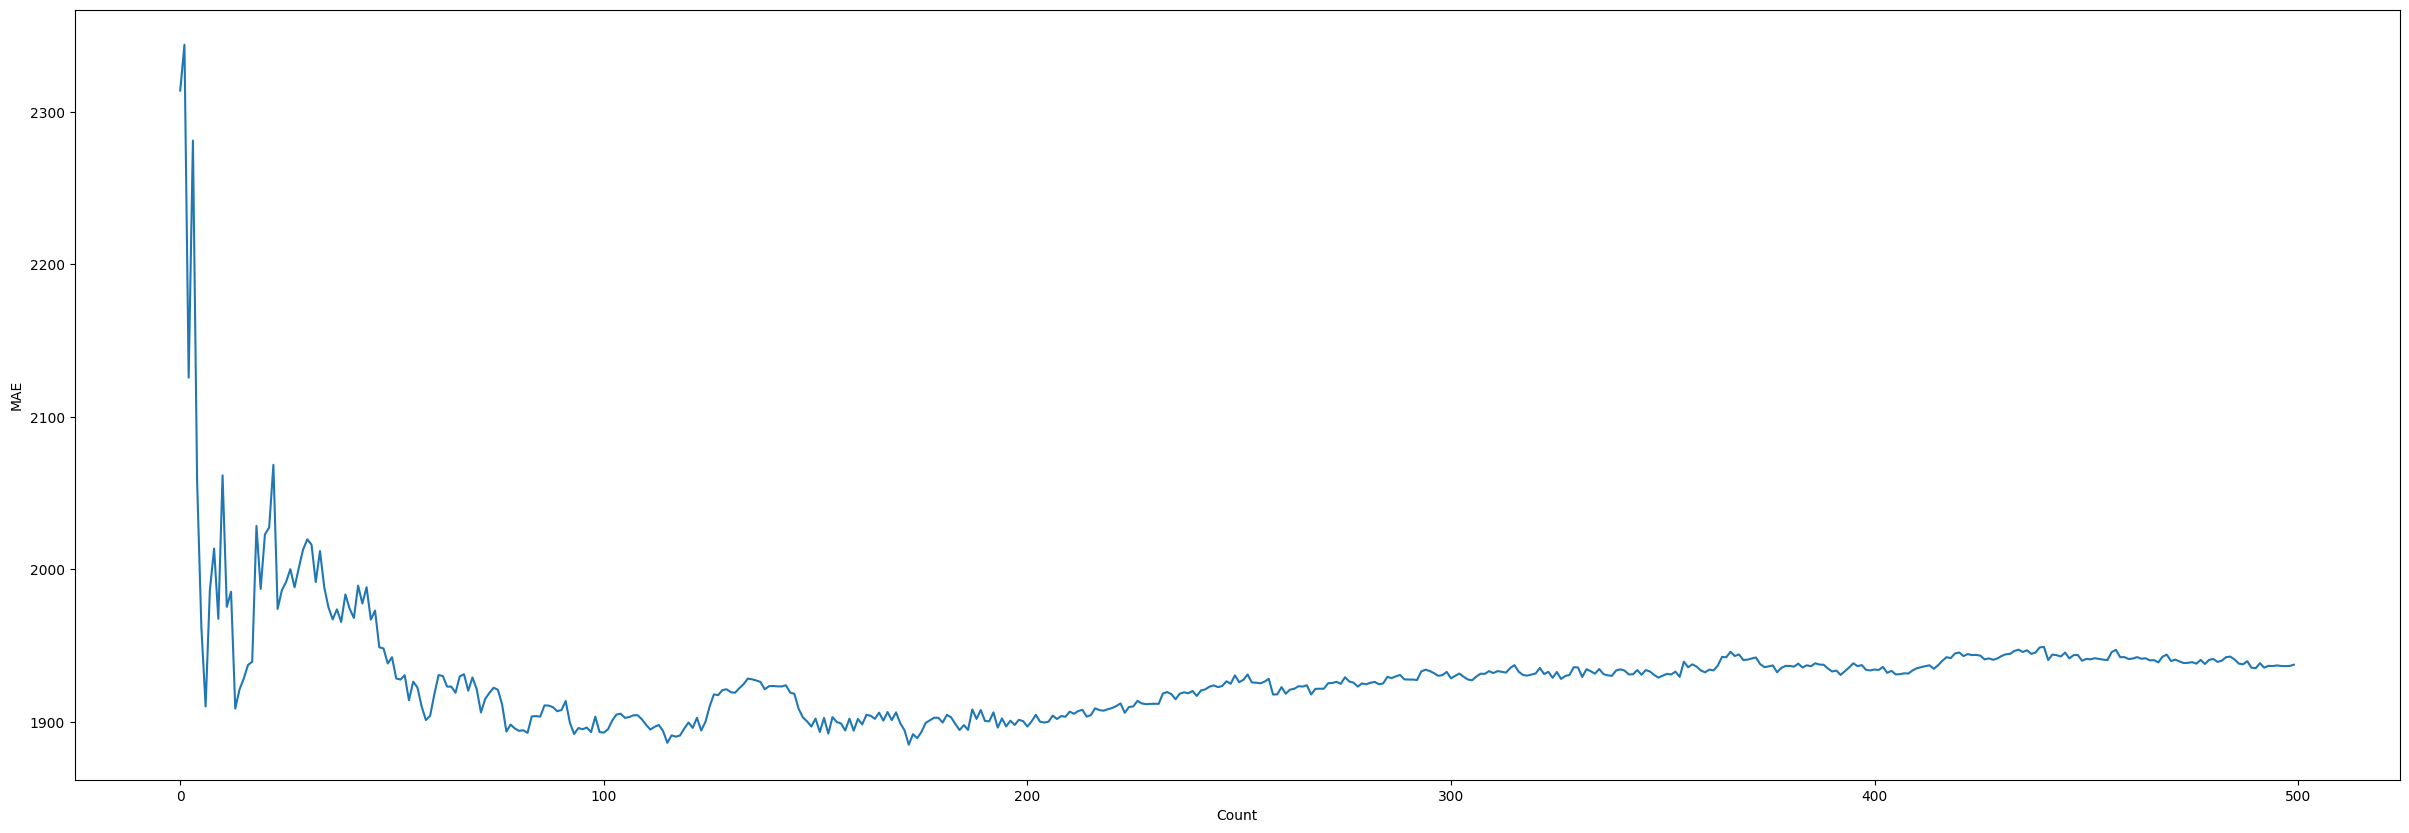

In [110]:
# 평균 절대 오차의 변화를 그래프로 시각화
plt.figure(figsize=(30, 10))
plt.plot(mae_list)
plt.xlabel('Count')
plt.ylabel('MAE')
plt.show()

In [112]:
importance = reg2.feature_importances_
cols = X.columns

importance_df = pd.DataFrame(
    zip(cols, importance),
    columns = ['feature_name', 'importance']
)

importance_df.sort_values('importance', ascending = False, inplace=True)
importance_df.reset_index(drop = True, inplace = True)
importance_df

,feature_name,importance
0,enginesize,0.505412
1,horsepower,0.109698
2,curbweight,0.103697
3,carwidth,0.076751
4,highwaympg,0.060431
5,carlength,0.046702
6,wheelbase,0.019063
7,boreratio,0.018254
8,citympg,0.016722
9,stroke,0.013491


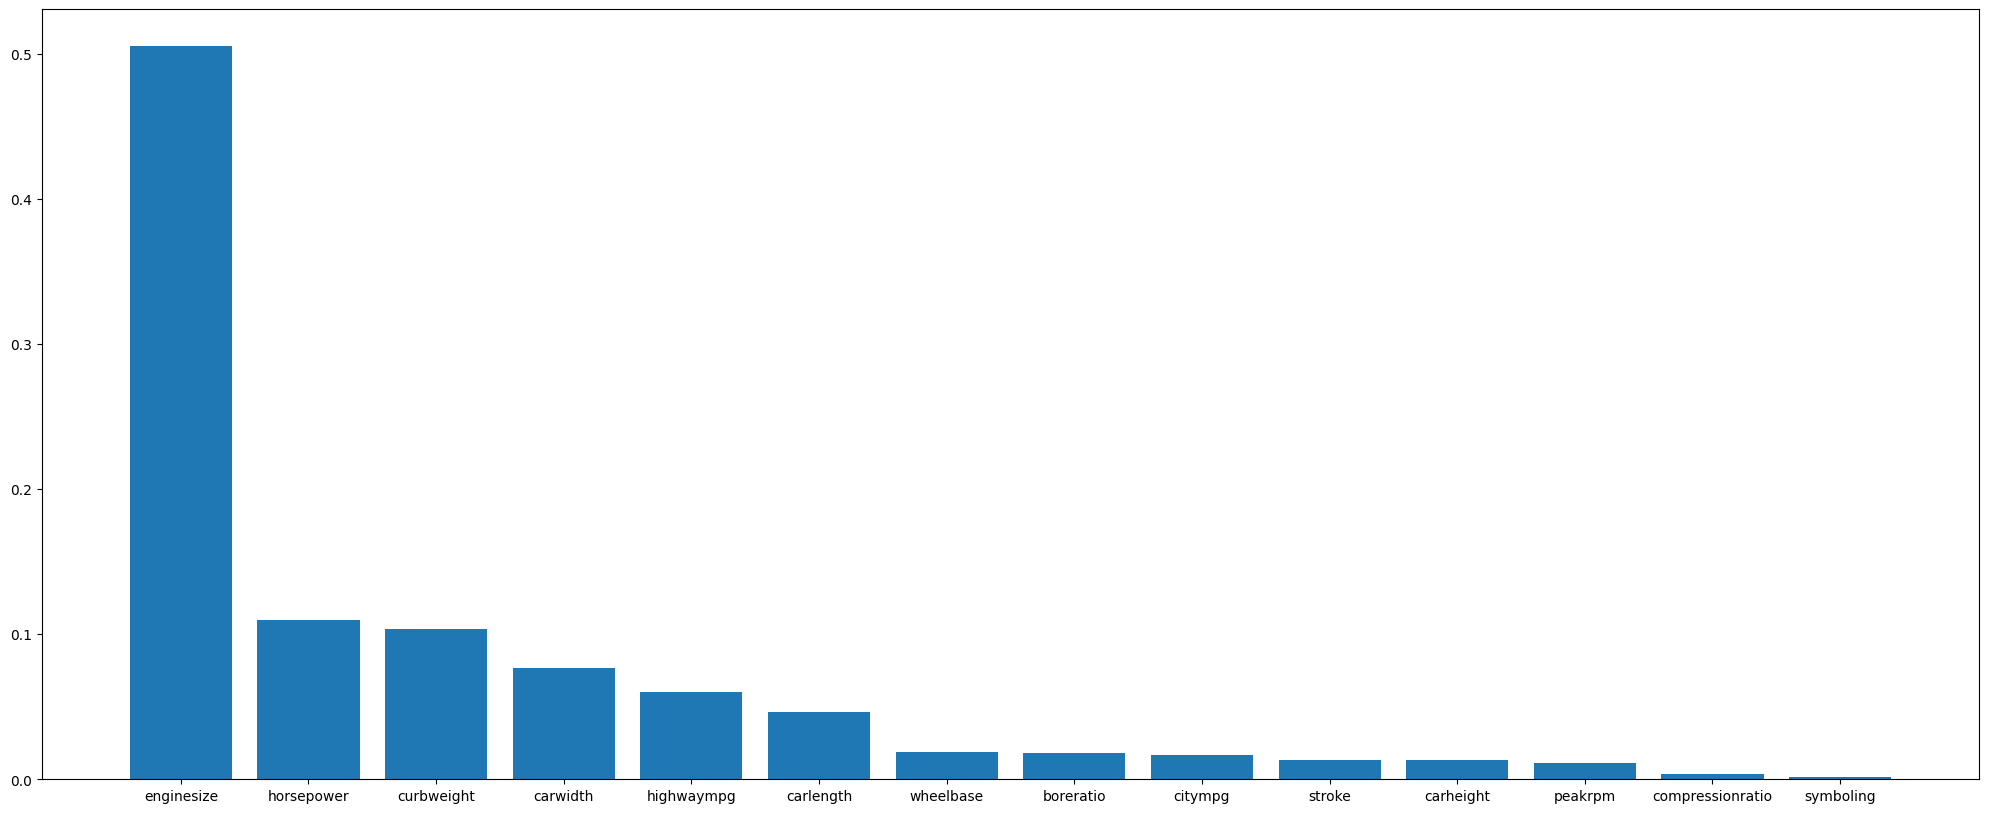

In [114]:
plt.figure(figsize = (25, 10))
plt.bar(importance_df['feature_name'], importance_df['importance'])
plt.show()